# Plot NorESM spinup-equilibrium diagnostics

This notebook reads the output produced by `check_spinup_equilibrium.sh` and plots the annual global/land-mean diagnostics.

Expected folder structure:

```text
equilibrium_output/
└── equilibrium_<CASENAME>_<COMP>/
    ├── cam_annual.nc or clm_annual.nc
    ├── cam_monthly.nc or clm_monthly.nc
    ├── summary.txt
    ├── VARIABLE.txt
    └── tmp/
```

Set `CASENAME` and `COMP` in the first code cell.


In [1]:
# -------------------------
# User settings
# -------------------------
from pathlib import Path

CASENAME = "NF2000norbc_tropstratchem_spinup_f19_f19"
COMP = "clm"   # "cam" or "clm"

# If the notebook is inside diagnostics/check-spinup-equilibrium,
# this default should work.
BASE_DIR = Path(".").resolve()

OUTDIR = BASE_DIR / "equilibrium_output" / f"equilibrium_{CASENAME}_{COMP}"

ANNUAL_FILE = OUTDIR / f"{COMP}_annual.nc"
MONTHLY_FILE = OUTDIR / f"{COMP}_monthly.nc"
SUMMARY_FILE = OUTDIR / "summary.txt"

print("OUTDIR:", OUTDIR)
print("Annual file exists:", ANNUAL_FILE.exists())
print("Monthly file exists:", MONTHLY_FILE.exists())
print("Summary file exists:", SUMMARY_FILE.exists())

if not OUTDIR.exists():
    raise FileNotFoundError(f"Output directory not found: {OUTDIR}")
if not ANNUAL_FILE.exists():
    raise FileNotFoundError(f"Annual file not found: {ANNUAL_FILE}")
if not SUMMARY_FILE.exists():
    raise FileNotFoundError(f"Summary file not found: {SUMMARY_FILE}")


OUTDIR: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/diagnostics/check-spinup-equilibrium/equilibrium_output/equilibrium_NF2000norbc_tropstratchem_spinup_f19_f19_clm
Annual file exists: True
Monthly file exists: True
Summary file exists: True


## Load packages and data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# xarray is convenient for plotting NetCDF output.
# If xarray is not available in your environment, install/load it in your conda/env.
import xarray as xr

ds_ann = xr.open_dataset(ANNUAL_FILE)
ds_mon = xr.open_dataset(MONTHLY_FILE) if MONTHLY_FILE.exists() else None

summary = pd.read_csv(SUMMARY_FILE, sep=r"\s+", engine="python")

display(summary)

print(ds_ann)


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/adelez/pyenv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/adelez/pyenv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/adelez/pyenv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/adelez/pyenv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/adelez/pyenv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 649, in get
    value = self._validate(obj, default

,var,first,last,drift,slope_per_year
0,TOTSOMN,;,;,0,0.0
1,TOTECOSYSN,;,;,0,0.0
2,TOTVEGC,;,;,0,0.0
3,TOTECOSYSC,;,;,0,0.0
4,TOTSOMC,;,;,0,0.0
5,TOTLITC,;,;,0,0.0
6,NPP,;,;,0,0.0
7,GPP,;,;,0,0.0
8,HR,;,;,0,0.0
9,NEE,;,;,0,0.0


<xarray.Dataset> Size: 16kB
Dimensions:      (time: 20, levsoi: 20, levgrnd: 25, hist_interval: 2)
Coordinates:
  * levgrnd      (levgrnd) float64 200B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
  * time         (time) object 160B 0001-07-16 22:00:00 ... 0020-07-16 22:00:00
Dimensions without coordinates: levsoi, hist_interval
Data variables: (12/23)
    GPP          (time) float64 160B ...
    H2OSNO       (time) float64 160B ...
    H2OSOI       (time, levsoi) float64 3kB ...
    HR           (time) float64 160B ...
    NBP          (time) float64 160B ...
    NEE          (time) float64 160B ...
    ...           ...
    area         float64 8B ...
    landarea     float64 8B ...
    landfrac     float64 8B ...
    lat          float64 8B ...
    lon          float64 8B ...
    time_bounds  (time, hist_interval) object 320B ...
Attributes: (12/101)
    title:                                     CLM History file information
    comment:                                   NOTE: None of t

## Clean up time axis

The NCO annual output may have a model-calendar time coordinate that is not decoded cleanly.  
For equilibrium diagnostics we mostly need the model-year index, so we create a simple `year_index` coordinate.

In [3]:
n_years = ds_ann.sizes.get("time", None)

if n_years is None:
    raise ValueError("No time dimension found in annual file.")

year_index = np.arange(1, n_years + 1)

# Assign a simple year index for plotting.
ds_ann = ds_ann.assign_coords(year_index=("time", year_index))

if ds_mon is not None and "time" in ds_mon.sizes:
    month_index = np.arange(1, ds_mon.sizes["time"] + 1)
    ds_mon = ds_mon.assign_coords(month_index=("time", month_index))

print(f"Number of annual time steps: {n_years}")


Number of annual time steps: 20


## Helper functions

In [4]:
def get_1d_series(ds, var):
    """Return a 1D time series for a variable.

    The NCO preprocessing should already have averaged lat/lon away.
    This function also squeezes singleton dimensions if present.
    """
    da = ds[var].squeeze(drop=True)
    if "time" not in da.dims:
        raise ValueError(f"{var} has no time dimension after squeezing. Dims: {da.dims}")
    extra_dims = [d for d in da.dims if d != "time"]
    if extra_dims:
        raise ValueError(f"{var} still has non-time dimensions: {extra_dims}. "
                         "This may need layer-specific plotting.")
    return da


def linear_fit(y):
    """Return slope and fitted line against 1-based year index."""
    x = np.arange(1, len(y) + 1)
    mask = np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.full_like(y, np.nan, dtype=float)
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    return slope, slope * x + intercept


def plot_variable(ds, var, unit=None):
    da = get_1d_series(ds, var)
    y = da.values.astype(float)
    slope, yfit = linear_fit(y)

    plt.figure(figsize=(8, 4))
    plt.plot(year_index, y, marker="o", linewidth=1)
    plt.plot(year_index, yfit, linestyle="--", linewidth=1)

    ylabel = var
    if unit:
        ylabel += f" [{unit}]"
    elif "units" in da.attrs:
        ylabel += f" [{da.attrs['units']}]"

    plt.xlabel("Model year")
    plt.ylabel(ylabel)
    plt.title(f"{CASENAME} | {COMP.upper()} | {var}\nSlope = {slope:.3e} per year")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot all annual diagnostics

This plots every variable listed in `summary.txt`, as long as it exists in the annual NetCDF file.

Variables available for plotting:
['TOTSOMN', 'TOTECOSYSN', 'TOTVEGC', 'TOTECOSYSC', 'TOTSOMC', 'TOTLITC', 'NPP', 'GPP', 'HR', 'NEE', 'NBP', 'TWS', 'H2OSOI', 'SOILLIQ', 'SOILICE', 'H2OSNO', 'TSOI']


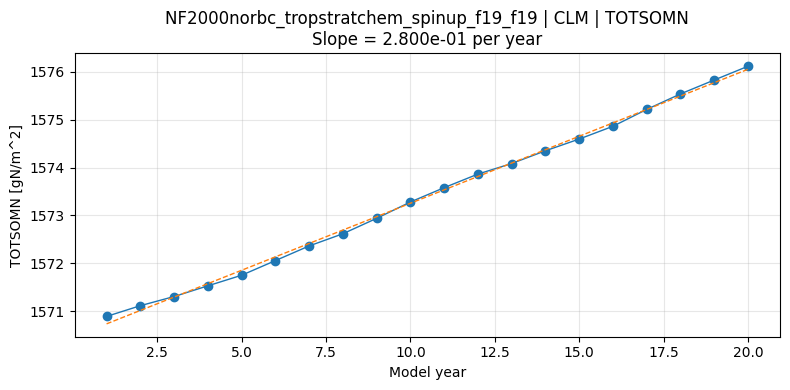

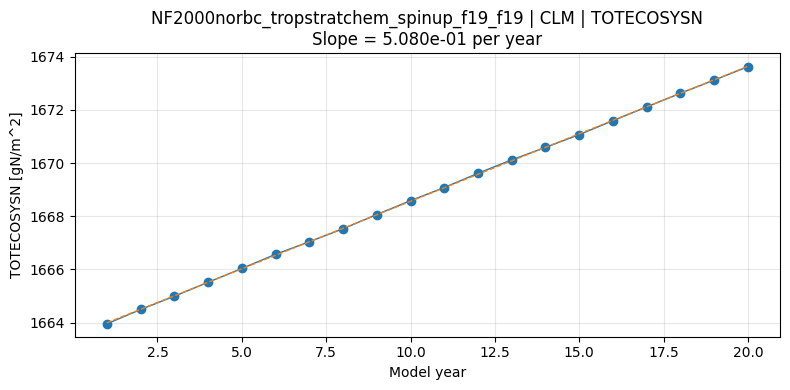

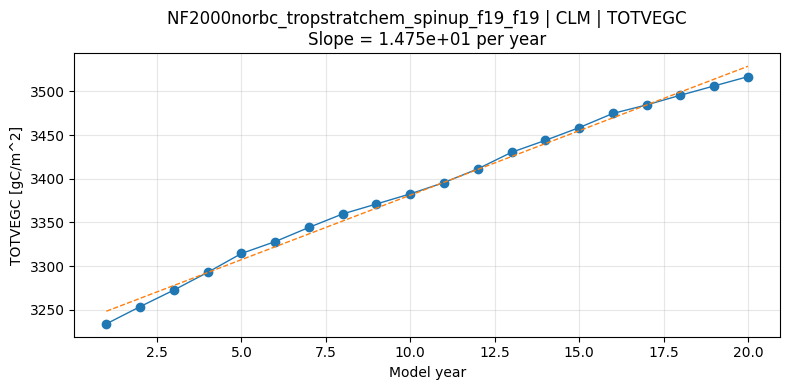

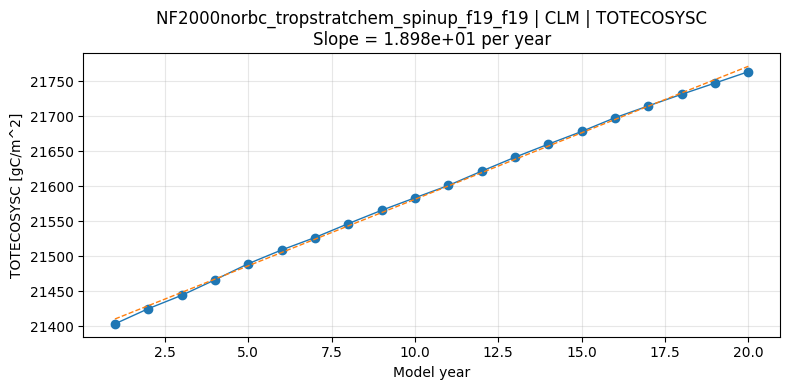

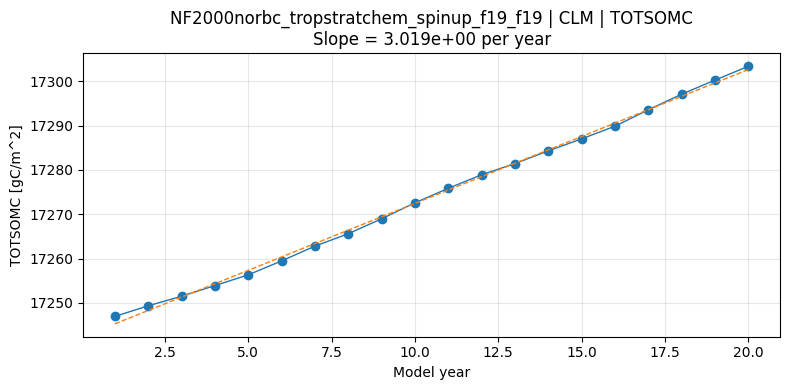

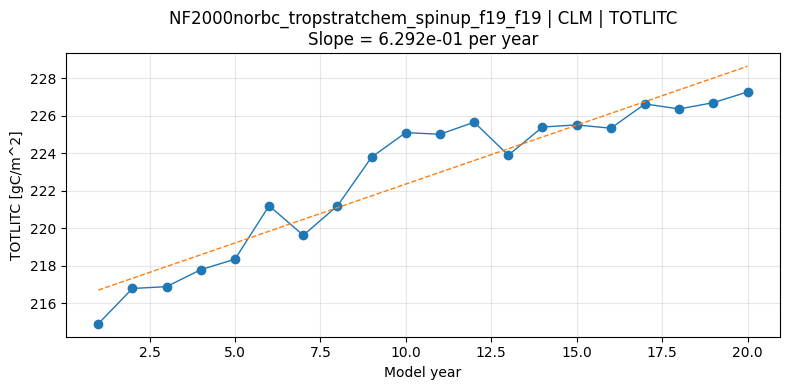

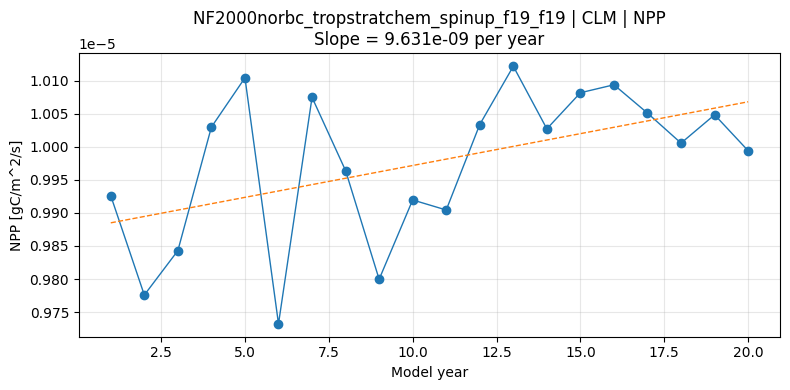

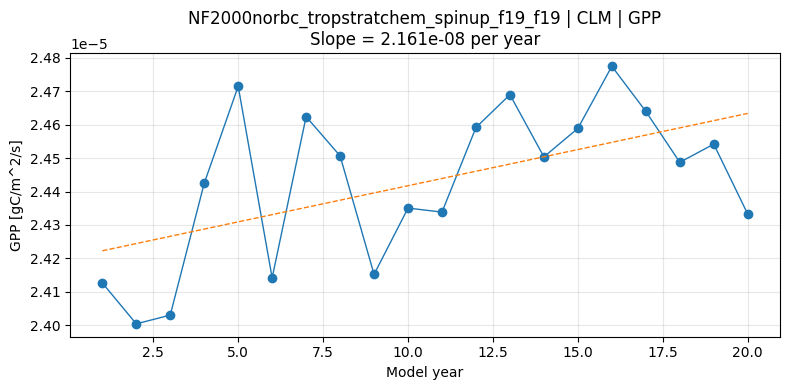

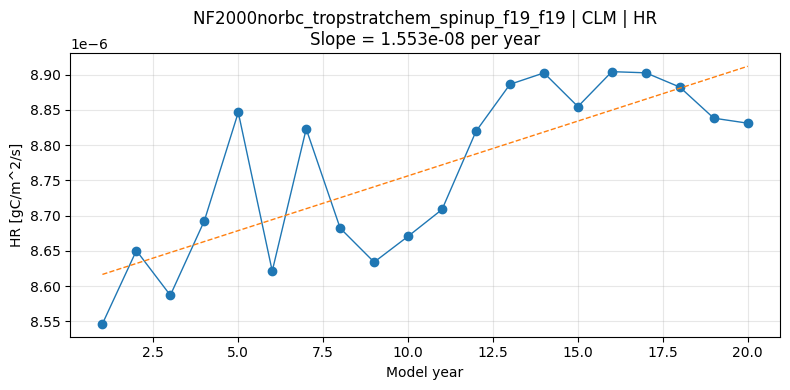

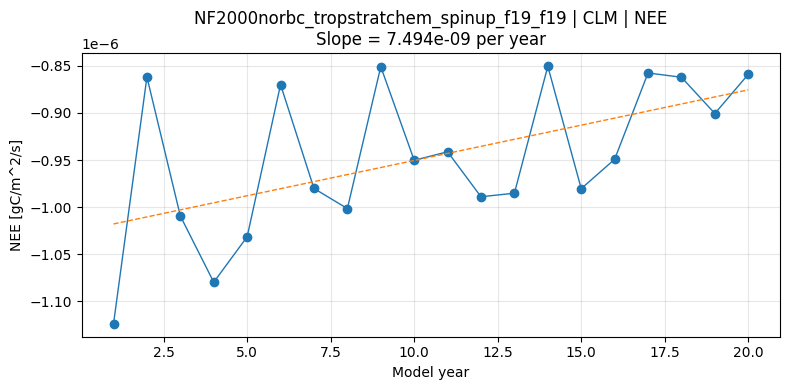

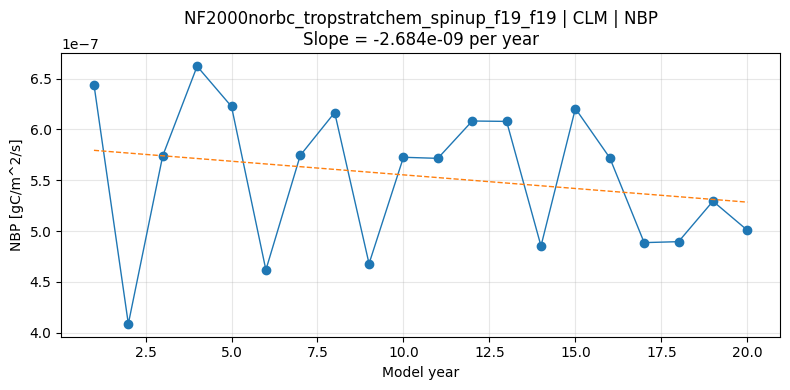

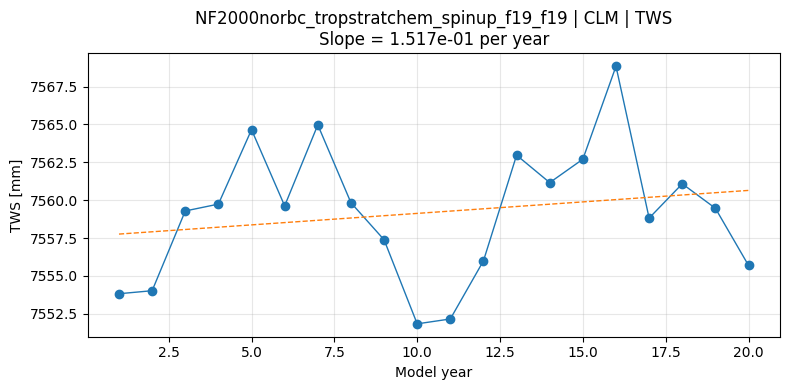

Skipping H2OSOI: H2OSOI still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.
Skipping SOILLIQ: SOILLIQ still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.
Skipping SOILICE: SOILICE still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.


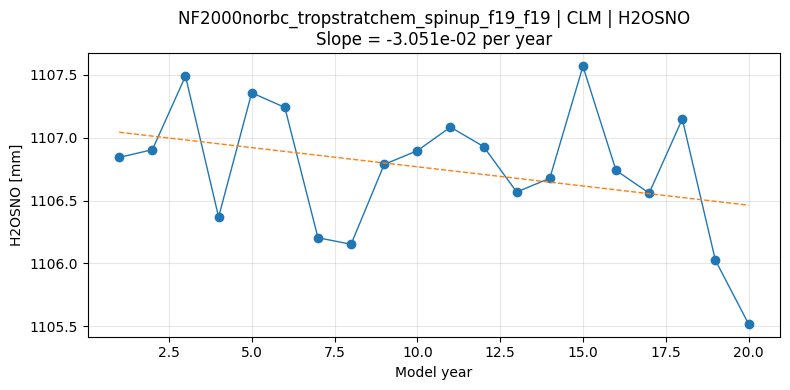

Skipping TSOI: TSOI still has non-time dimensions: ['levgrnd']. This may need layer-specific plotting.


In [5]:
variables = [v for v in summary["var"].tolist() if v in ds_ann.data_vars]

print("Variables available for plotting:")
print(variables)

for var in variables:
    try:
        plot_variable(ds_ann, var)
    except Exception as e:
        print(f"Skipping {var}: {e}")


## CAM-specific quick-look plots

For CAM, these are the first diagnostics I would inspect: `RESTOM`, `TREFHT`, `PRECT`, `PSL`, and `CLDTOT`.

`PRECT` is usually stored in m/s. The notebook also plots it as mm/day if available.


In [ ]:
if COMP == "cam":
    cam_priority = ["RESTOM", "TREFHT", "PRECT", "PSL", "CLDTOT"]

    for var in cam_priority:
        if var in ds_ann:
            if var == "PRECT":
                da = get_1d_series(ds_ann, "PRECT")
                y = da.values.astype(float) * 1000 * 86400  # m/s -> mm/day
                slope, yfit = linear_fit(y)

                plt.figure(figsize=(8, 4))
                plt.plot(year_index, y, marker="o", linewidth=1)
                plt.plot(year_index, yfit, linestyle="--", linewidth=1)
                plt.xlabel("Model year")
                plt.ylabel("PRECT [mm/day]")
                plt.title(f"{CASENAME} | CAM | PRECT\nSlope = {slope:.3e} mm/day/year")
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
            else:
                plot_variable(ds_ann, var)
        else:
            print(f"{var} not found in annual file.")


## CLM-specific quick-look plots

For CLM, storage variables matter most for spinup equilibrium. NPP can look stable while carbon, nitrogen, water, or soil temperature are still drifting.


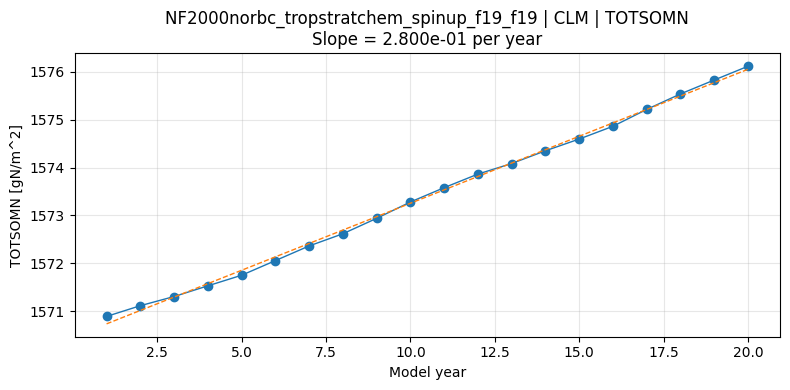

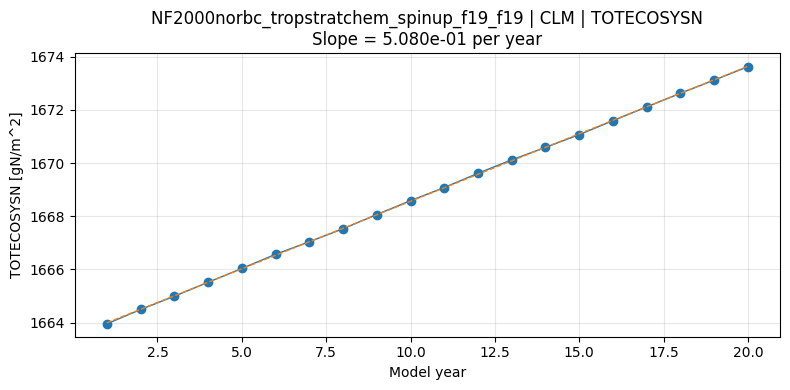

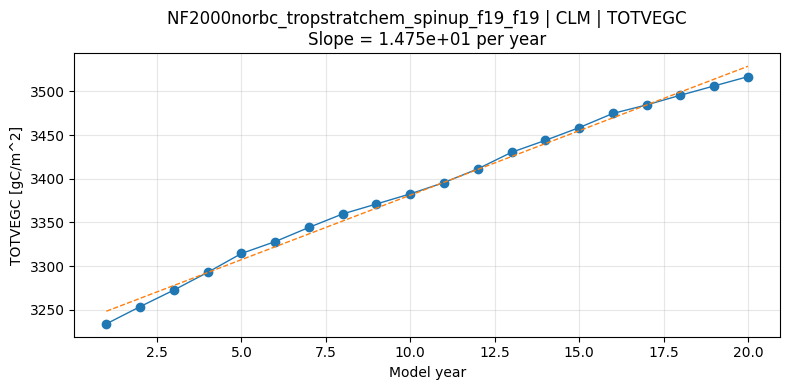

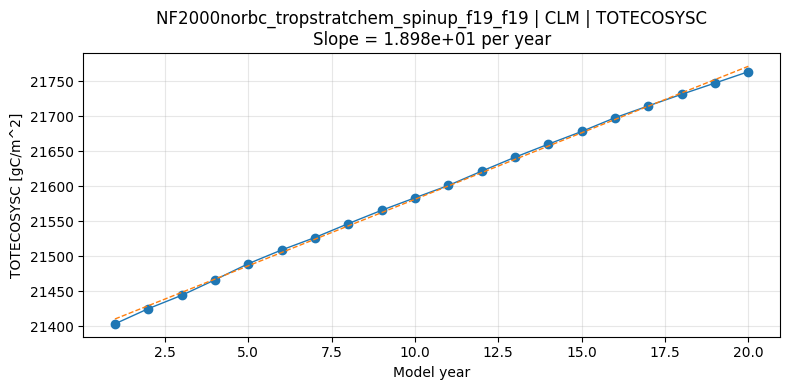

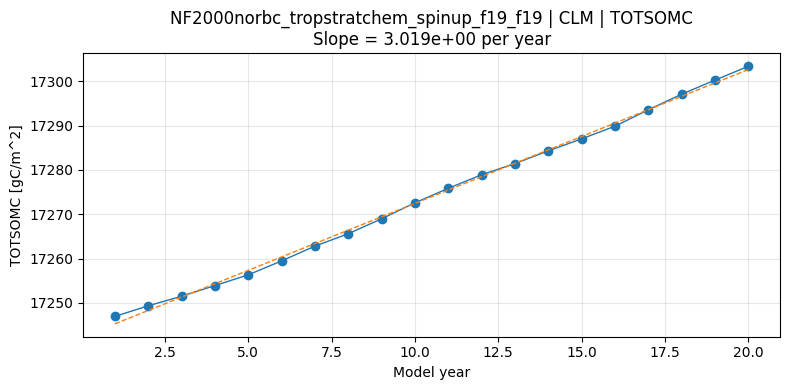

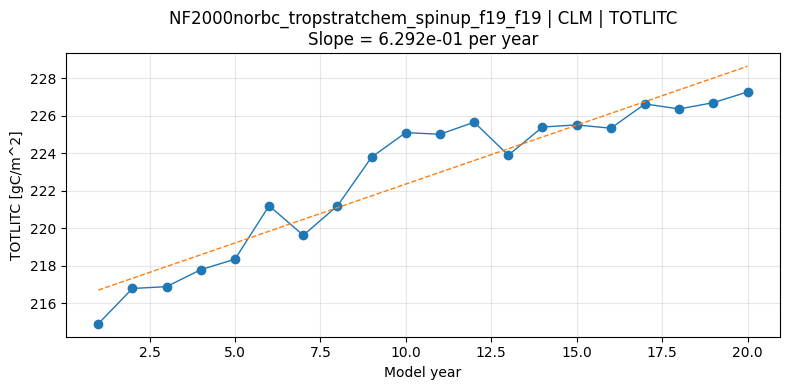

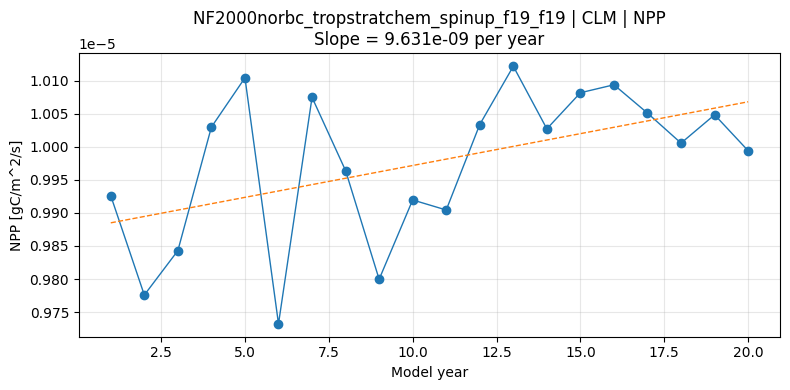

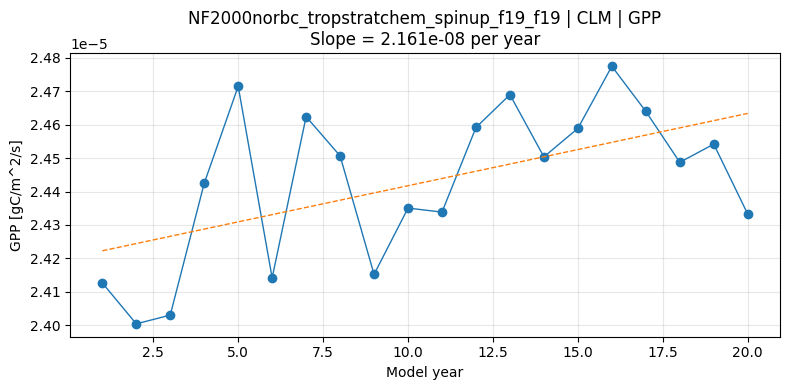

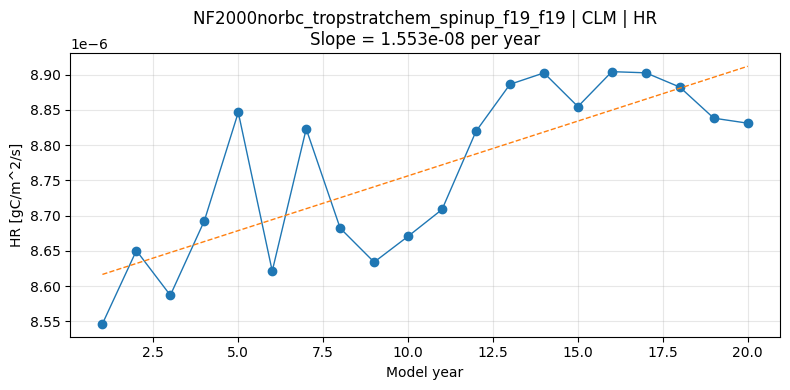

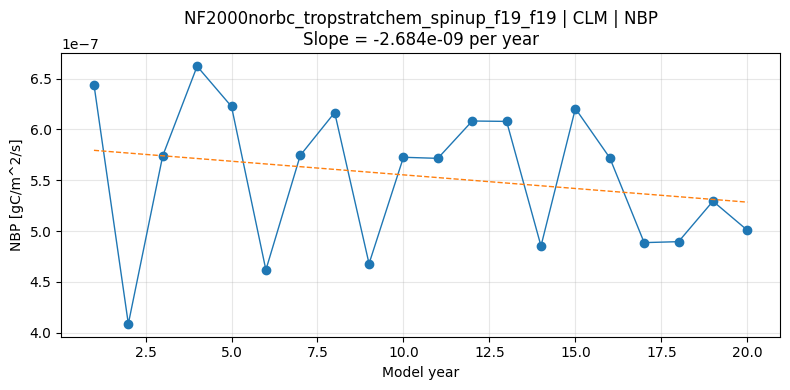

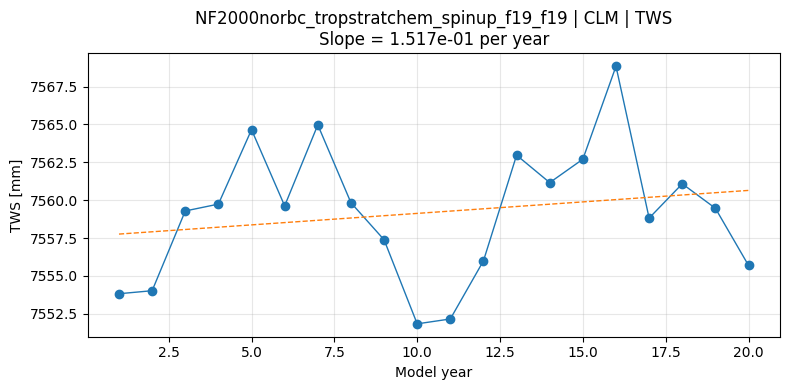

Skipping H2OSOI: H2OSOI still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.
Skipping SOILLIQ: SOILLIQ still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.
Skipping SOILICE: SOILICE still has non-time dimensions: ['levsoi']. This may need layer-specific plotting.


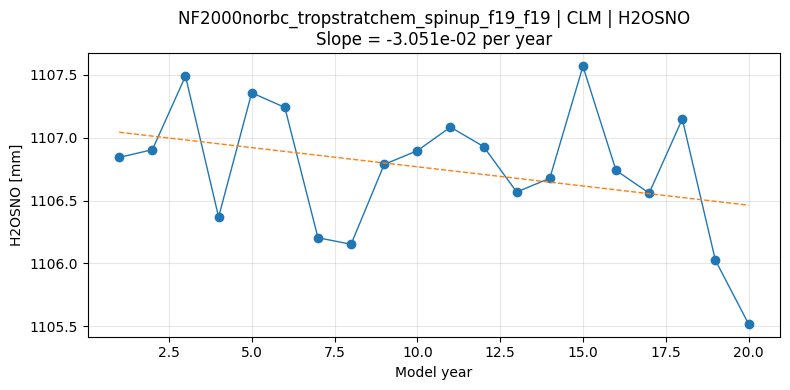

Skipping TSOI: TSOI still has non-time dimensions: ['levgrnd']. This may need layer-specific plotting.


In [6]:
if COMP == "clm":
    clm_priority = [
        "TOTSOMN", "TOTECOSYSN",
        "TOTVEGC", "TOTECOSYSC", "TOTSOMC", "TOTLITC",
        "NPP", "GPP", "HR", "NBP",
        "TWS", "H2OSOI", "SOILLIQ", "SOILICE", "H2OSNO",
        "TSOI"
    ]

    for var in clm_priority:
        if var in ds_ann:
            try:
                plot_variable(ds_ann, var)
            except Exception as e:
                print(f"Skipping {var}: {e}")
        else:
            print(f"{var} not found in annual file.")


## Summary table sorted by absolute trend

This helps identify which variables still have the largest drift.

In [ ]:
summary2 = summary.copy()
summary2["abs_slope_per_year"] = pd.to_numeric(summary2["slope_per_year"], errors="coerce").abs()
summary2["abs_drift"] = pd.to_numeric(summary2["drift"], errors="coerce").abs()

summary2 = summary2.sort_values("abs_slope_per_year", ascending=False)

display(summary2)


## Optional: save all plots to PNG

Set `SAVE_PLOTS = True` if you want one PNG per variable in the same output directory.


In [ ]:
SAVE_PLOTS = False

if SAVE_PLOTS:
    figdir = OUTDIR / "figures"
    figdir.mkdir(exist_ok=True)

    for var in variables:
        try:
            da = get_1d_series(ds_ann, var)
            y = da.values.astype(float)
            slope, yfit = linear_fit(y)

            plt.figure(figsize=(8, 4))
            plt.plot(year_index, y, marker="o", linewidth=1)
            plt.plot(year_index, yfit, linestyle="--", linewidth=1)
            plt.xlabel("Model year")
            ylabel = var
            if "units" in da.attrs:
                ylabel += f" [{da.attrs['units']}]"
            plt.ylabel(ylabel)
            plt.title(f"{CASENAME} | {COMP.upper()} | {var}\nSlope = {slope:.3e} per year")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(figdir / f"{COMP}_{var}_annual.png", dpi=150)
            plt.close()
        except Exception as e:
            print(f"Skipping {var}: {e}")

    print(f"Saved figures to: {figdir}")
